# **Telecom Customer Churn Prediction**

## 1. Problem Statement

Customer churn occurs when a customer stops using a company's services. The
objective of this project is to build a machine learning model that predicts
whether a telecommunications customer is likely to churn.

The project will also investigate which customer characteristics are associated
with churn. The results could help a telecommunications company identify
high-risk customers and develop targeted retention strategies.

The target variable is `Churn`:

- `No`: The customer remained with the company.
- `Yes`: The customer left the company.

## 2. Dataset Description

In [82]:
from google.colab import drive
drive.mount("/content/drive")
### Loading the dataset- The dataset is loaded from Google Drive so that it remains available after the Colab runtime disconnects. I then inspect the first five rows to confirm that the file loaded correctly.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/ML Projects/Telco Churn")
DATA_PATH = PROJECT_DIR / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
OUTPUT_DIR = PROJECT_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", DATA_PATH.exists())
print("Dataset path:", DATA_PATH)

Dataset exists: True
Dataset path: /content/drive/MyDrive/ML Projects/Telco Churn/data/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
# df.shape returns the number of rows and columns
number_of_rows, number_of_columns = df.shape

print("Number of customer records:", number_of_rows)
print("Number of columns:", number_of_columns)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Number of customer records: 7043
Number of columns: 21


The original dataset contains 7,043 customer records and 21 columns. Each row
represents one customer. The columns contain customer characteristics and the
target variable, `Churn`.

The column names are examined to identify the available predictors and the
target variable.

In [85]:
# Display each column name and its position
for position, column in enumerate(df.columns, start=1):
    print(f"{position}. {column}")

1. customerID
2. gender
3. SeniorCitizen
4. Partner
5. Dependents
6. tenure
7. PhoneService
8. MultipleLines
9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


In [86]:
# Show each column's data type and number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset contains a mixture of numerical and categorical variables.
`TotalCharges` is currently stored as an object despite representing a monetary
amount. This suggests that the column may contain non-numeric values and should
be investigated during data cleaning.

###Summary Statistics

Descriptive statistics will be generated to understand the numerical ranges and the
most common values in categorical columns.

In [87]:
# Generate descriptive statistics for numerical columns
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [88]:
# Generate descriptive statistics for text and categorical columns
display(df.describe(include="object").T)

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### Target Variable

The possible values in the target column are inspected to confirm that this is
a binary classification problem. A more detailed analysis and visualization of
class balance will be performed during exploratory data analysis.

In [89]:
# Display the possible target values and their frequencies
print("Target categories:", df["Churn"].unique())

display(
    df["Churn"]
      .value_counts()
      .rename_axis("Churn")
      .reset_index(name="Customer Count")
)

Target categories: ['No' 'Yes']


,Churn,Customer Count
0,No,5174
1,Yes,1869


### Initial Inspection Summary

The dataset loaded successfully and contains customer-level demographic,
service, contract, and billing information. Each row represents one customer,
and the dataset contains 7,043 records and 21 columns.

The target variable, `Churn`, contains two categories: `Yes` and `No`. This
confirms that the project is a binary classification problem.

The initial inspection also identified a potential data-type issue:
`TotalCharges` is stored as an object instead of a numerical variable. Missing
values, duplicate records, invalid values, and the `TotalCharges` data-type
issue will be examined during data cleaning.

## 3. Data Quality and Cleaning

Before any type of exploratory analysis or training machine learning models, the
dataset must be checked for duplicate records, missing values, incorrect data
types, invalid values, and unnecessary identifiers.

A copy of the original dataset will be preserved so that the effects of cleaning
can be reviewed later `(backup)`.

In [90]:
# To keep an unchanged copy of the original dataset
df_original = df.copy()

print("Original dataset shape:", df_original.shape)

Original dataset shape: (7043, 21)


In [91]:
# Count rows that are exact duplicates
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


No exact duplicate rows were identified, so no records were removed at this
stage.

### Customer Identifier

The `customerID` column should uniquely identify each customer. Duplicate or
missing customer IDs could indicate data-set problems.

In [92]:
# Check whether customerID contains missing or duplicated values
missing_customer_ids = df["customerID"].isna().sum()
duplicate_customer_ids = df["customerID"].duplicated().sum()
unique_customer_ids = df["customerID"].nunique()

print("Missing customer IDs:", missing_customer_ids)
print("Duplicate customer IDs:", duplicate_customer_ids)
print("Unique customer IDs:", unique_customer_ids)

Missing customer IDs: 0
Duplicate customer IDs: 0
Unique customer IDs: 7043


The `customer id` is complete and unique, However, it's only
an identifier and does not describe customer behavior. It will be excluded
before model training because identifiers should not be used as predictive
features.

### Missing Values

Missing values are checked across all columns. Standard missing-value detection
may not identify blank strings, so text columns will also be examined
separately.

In [93]:
# Count standard missing values in every column
missing_values = df.isna().sum()

# Display only columns containing at least one missing value
missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

if missing_values.empty:
    print("No standard missing values were detected.")
else:
    display(missing_values.to_frame(name="Missing Values"))

No standard missing values were detected.


In [94]:
# Select columns currently stored as text
text_columns = df.select_dtypes(include="object").columns

# Count empty or whitespace-only strings in every text column
blank_counts = pd.Series({
    column: df[column].astype(str).str.strip().eq("").sum()
    for column in text_columns
})

# Keep only columns that contain blank strings
blank_counts = blank_counts[blank_counts > 0].sort_values(ascending=False)

if blank_counts.empty:
    print("No blank strings were detected.")
else:
    display(blank_counts.to_frame(name="Blank Strings"))

,Blank Strings
TotalCharges,11


Although pandas initially reported no standard missing values, blank strings
were found in `TotalCharges`. These blanks explain why the column was imported
as text instead of as a numerical variable.

### Correcting `TotalCharges`

`TotalCharges` represents a monetary amount and should therefore be numerical.
It is converted to a numeric data type. Blank or otherwise invalid values are
converted to missing values so they can be handled explicitly.

In [95]:
# Convert TotalCharges from text to numeric
# errors="coerce" changes blank or invalid entries into NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges values:", df["TotalCharges"].isna().sum())

TotalCharges data type: float64
Missing TotalCharges values: 11


Before removing or replacing missing values, the affected records will be inspected to determine whether there is a meaningful pattern.

In [96]:
# Display relevant fields for customers with missing TotalCharges
missing_total_charges = df.loc[
    df["TotalCharges"].isna(),
    [
        "customerID",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
]

display(missing_total_charges)

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,Two year,52.55,NaN,No
753,3115-CZMZD,0,Two year,20.25,NaN,No
936,5709-LVOEQ,0,Two year,80.85,NaN,No
1082,4367-NUYAO,0,Two year,25.75,NaN,No
1340,1371-DWPAZ,0,Two year,56.05,NaN,No
3331,7644-OMVMY,0,Two year,19.85,NaN,No
3826,3213-VVOLG,0,Two year,25.35,NaN,No
4380,2520-SGTTA,0,Two year,20.00,NaN,No
5218,2923-ARZLG,0,One year,19.70,NaN,No
6670,4075-WKNIU,0,Two year,73.35,NaN,No


The records with missing (NaN) `TotalCharges` have a tenure of zero months, possibly suggesting that they are new customers who have not yet accumulated a total charge, meaning this is'nt missing data.

The affected records will be removed as they represent a very small proportion of the full dataset. They will be removed because `TotalCharges` is an important numerical feature and removing this has a small chance of changing the analysis.

In [97]:
# Dataset before removal of incomplete records
rows_before = len(df)

# Dropping records with missing TotalCharges
df = df.dropna(subset=["TotalCharges"]).copy()

# reset row index after dropping
df = df.reset_index(drop=True)

# Dataset after removal of incomplete records
rows_after = len(df)
rows_removed = rows_before - rows_after
percentage_removed = (rows_removed / rows_before) * 100

print("Rows before removal:", rows_before)
print("Rows after removal:", rows_after)
print("Rows removed:", rows_removed)
print(f"Percentage removed: {percentage_removed:.2f}%")



Rows before removal: 7043
Rows after removal: 7032
Rows removed: 11
Percentage removed: 0.16%


### Categorical values

The unique values in each categorical colomn will be inspected for inconsistent spelling, unexpected categories, and extra whitespaces.

In [98]:
# Display the distinct values in every text colomn
for column in df.select_dtypes(include="object").columns:
    unique_values = sorted(df[column].dropna().astype(str).unique())

    print(f"\n{column} ({len(unique_values)} unique values):")
    print(unique_values)


customerID (7032 unique values):
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW',

Categories such as`No Phone service` and `No internet service` contain meaningful information and will not be treated as missing values.

### Numerical Value Ranges

The numerical variables are checked for impossible values such as a negative tenure or negative charges.

In [99]:
# Display the minimum and maximum values for the numerical variation
numerical_ranges = df.select_dtypes(include=np.number).agg(["min", "max"]).T

display(numerical_ranges)

,min,max
SeniorCitizen,0.00,1.00
tenure,1.00,72.00
MonthlyCharges,18.25,118.75
TotalCharges,18.80,8684.80


In [100]:
#check specifically for the impossible negative values
print("Negative tenure values:", (df["tenure"] < 0).sum())
print(
    "Negative MonthlyCharges values:",
    (df["MonthlyCharges"] < 0).sum()
)
print(
    "Negative TotalCharges values:",
    (df["TotalCharges"] < 0).sum()
)

Negative tenure values: 0
Negative MonthlyCharges values: 0
Negative TotalCharges values: 0


No negative values were returned in the tenure or charge variables. Their observed ranges are good for this dataset.

### Data cleaning recap

The cleaned dataset is checked again to confirm that the corrections were successful.

In [101]:
# verify the cleaned dataset
print("Cleaned dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isna().sum().sum())
print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Unique customer IDs:", df["customerID"].nunique())

Cleaned dataset shape: (7032, 21)
Duplicate rows: 0
Total missing values: 0
TotalCharges data type: float64
Unique customer IDs: 7032


In [102]:
# Create a permanent folder for processed data
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Define the output path without overwriting the original CSV
CLEANED_DATA_PATH = PROCESSED_DATA_DIR / "telco_churn_cleaned.csv"

# Save the cleaned dataset
df.to_csv(CLEANED_DATA_PATH, index=False)

print("Cleaned dataset saved to:")
print(CLEANED_DATA_PATH)
print("File exists:", CLEANED_DATA_PATH.exists())

Cleaned dataset saved to:
/content/drive/MyDrive/ML Projects/Telco Churn/data/processed/telco_churn_cleaned.csv
File exists: True


### Data Cleaning Summary

The dataset was examined for duplicate records, missing values, invalid
numerical ranges, inconsistent categories, and identifier problems.

No duplicate records or duplicate customer IDs were found. The `TotalCharges`
column was initially stored as text because it contained blank strings. It was
converted to a numerical data type, which exposed 11 missing values. These
records represented customers with zero months of tenure and accounted for
approximately 0.16% of the dataset, so they were removed.

After cleaning, the dataset contains 7,032 customer records and 21 columns, with
no remaining missing values or exact duplicates. The cleaned dataset was saved
separately so that the original data remains unchanged.

## 4. Exploratory Data Analysis

Exploratory data analysis is used to understand the cleaned dataset and identify
patterns associated with customer churn. The analysis examines the target
distribution, customer tenure, billing variables, contracts, services, payment
methods, and demographic characteristics.

The visualizations show associations rather than causal relationships. A pattern
associated with churn does not necessarily cause customers to leave.

In [103]:
# First to create a seperate copy for exploratory analyis
eda_df = df.copy()

# A nu,erical version of churn for calculating churn rates
# Yes will be 1 and No 0
eda_df["ChurnFlag"] = eda_df["Churn"].map({
    "No": 0,
    "Yes": 1
})
print("EDA Dataset shape:", eda_df.shape)
display(eda_df.head())

EDA Dataset shape: (7032, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


### Customer Churn Distribution

The distribution of the target variable is examined to determine whether the
classes are balanced. Class imbalance is important because a model could achieve
high accuracy by primarily predicting the majority class.

In [104]:
# calculate the number and percentage of customers in each class
churn_counts = eda_df["Churn"].value_counts()
churn_percentages = (
    eda_df["Churn"].value_counts(normalize=True) * 100
)

churn_summary = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage": churn_percentages
})

display(churn_summary.round(2))

,Customer Count,Percentage
Churn,,
No,5163,73.42
Yes,1869,26.58


/tmp/ipykernel_1496/1929703113.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


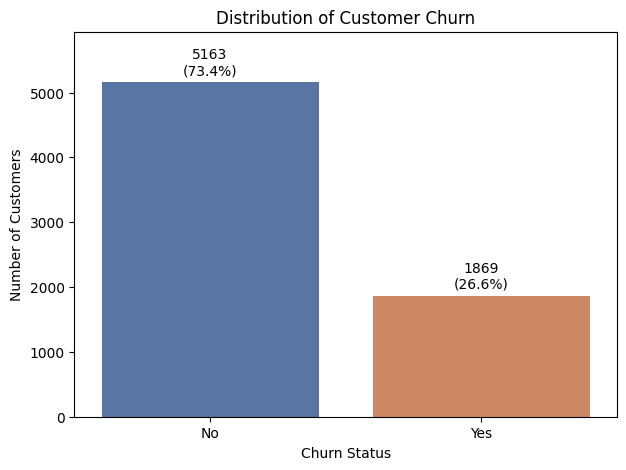

In [105]:
# for chart
# define the order and colors used in chart
churn_order = ["No", "Yes"]
churn_colors = ["#4C72B0", "#DD8452"]

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=eda_df,
    x="Churn",
    order=churn_order,
    palette=churn_colors,
    legend=False
)

#To add percentages above bars
total_customers = len(eda_df)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.0f}\n"
        f"({bar.get_height() / total_customers * 100:.1f}%)"
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.ylim(0, churn_counts.max() * 1.15)

# Save the chart permanently
plt.savefig(
    OUTPUT_DIR / '01_churn_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Most customers after atleast a month remained with the company (73.4%), while a smaller proportion churned (26.6%).
The dataset therefore has a moderate class imbalance. Consequently, model
performance should not be evaluated using accuracy alone. Precision, recall,
F1 score, and ROC-AUC will also be considered.

### Numerical Feature Distributions

The distributions of tenure, monthly charges, and total charges are examined to
understand their ranges, shapes, and concentrations.

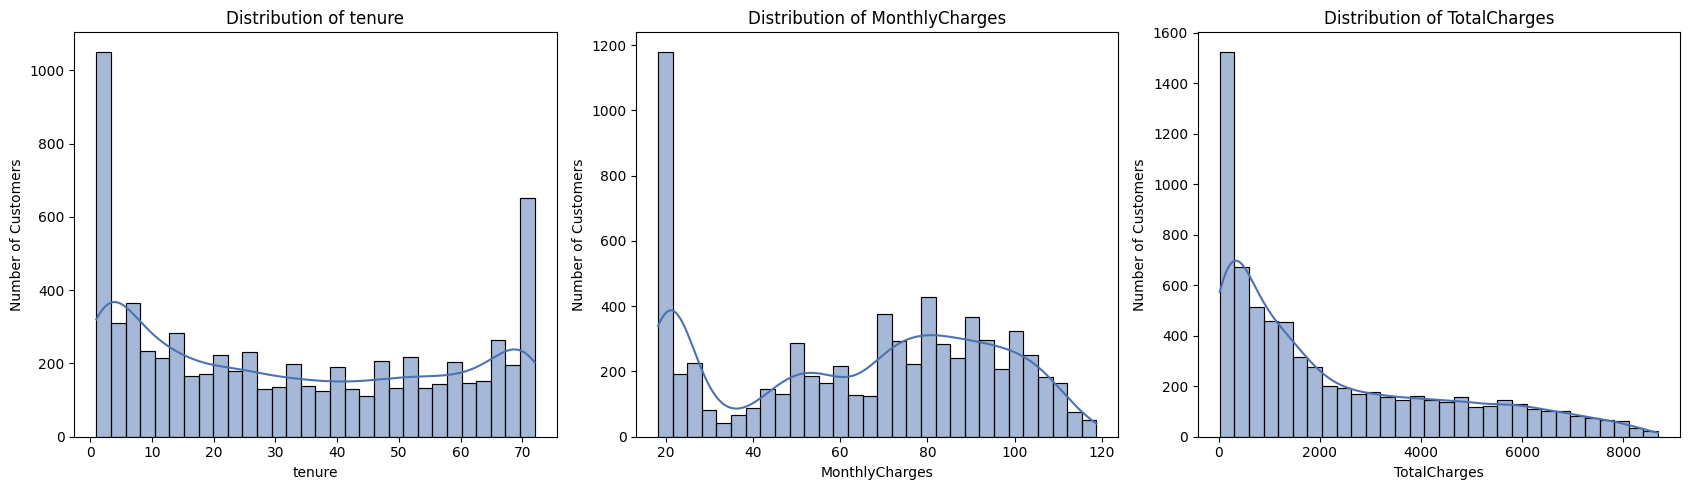

In [106]:
# Numerical variables selected for distribution analysis
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Create histogram for each variable
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for axis, feature in zip(axes, numerical_features):
    sns.histplot(
        data=eda_df,
        x=feature,
        bins=30,
        kde=True,
        color="#4C72B0",
        ax=axis
    )

    axis.set_title(f"Distribution of {feature}")
    axis.set_xlabel(feature)
    axis.set_ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / '02_numerical_distributions.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Interpretation of Numerical Distributions

The tenure distribution is not symmetric. There is a large concentration of
customers with very short tenure and another concentration near the maximum
tenure of approximately 72 months. This indicates that the dataset contains
both many recently acquired customers and many long-standing customers.

Monthly charges range from approximately 18 to 119. There is a noticeable
concentration near the lower end, followed by another broader concentration
between approximately 70 and 100. This may reflect customers subscribing to
different combinations of telecommunications services.

Total charges have a strongly right-skewed distribution. Most customers have
relatively low total charges, while a smaller number have accumulated much
larger charges. Because total charges accumulate over time, this pattern is
likely related to customer tenure as well as monthly charges.

### Customer Tenure and Churn

Tenure measures the number of months a customer has remained with the company.
Its relationship with churn is examined to determine whether newer or
long-standing customers display different churn behavior.

In [107]:
# Calculate tenure statistics for each churn group
tenure_summary = (
    eda_df.groupby("Churn")["tenure"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

display(tenure_summary)

,count,mean,median,min,max
Churn,,,,,
No,5163,37.65,38.0,1,72
Yes,1869,17.98,10.0,1,72


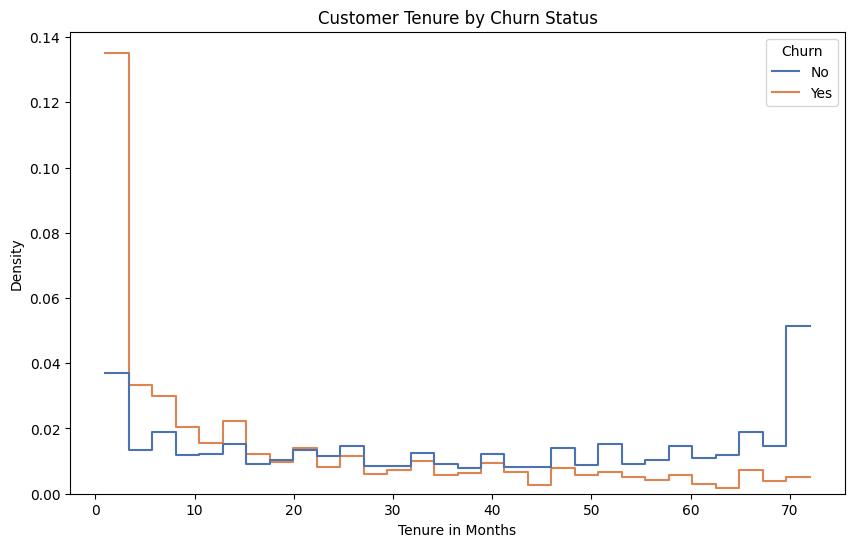

In [108]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="tenure",
    hue="Churn",
    hue_order=["No", "Yes"],
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    palette=churn_colors
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Tenure in Months")
plt.ylabel("Density")

plt.savefig(
    OUTPUT_DIR / '03_tenure_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Customers who churned generally had a lower tenure than customers who remained.
This suggests that the early stages of the customer relationship may be an
important period for retention efforts. However, this is an association and
does not establish that short tenure causes churn.

### Customer Charges and Churn

Monthly and total charges are compared across churn groups to determine whether
billing characteristics are associated with customers leaving.

In [109]:
# Compare charge statistics across churn groups
charge_summary = (
    eda_df.groupby("Churn")[
        ["MonthlyCharges", "TotalCharges"]
    ]
    .agg(["mean", "median"])
    .round(2)
)

display(charge_summary)

MonthlyCharges        TotalCharges         
                mean median         mean   median
Churn                                            
No             61.31  64.45      2555.34  1683.60
Yes            74.44  79.65      1531.80   703.55

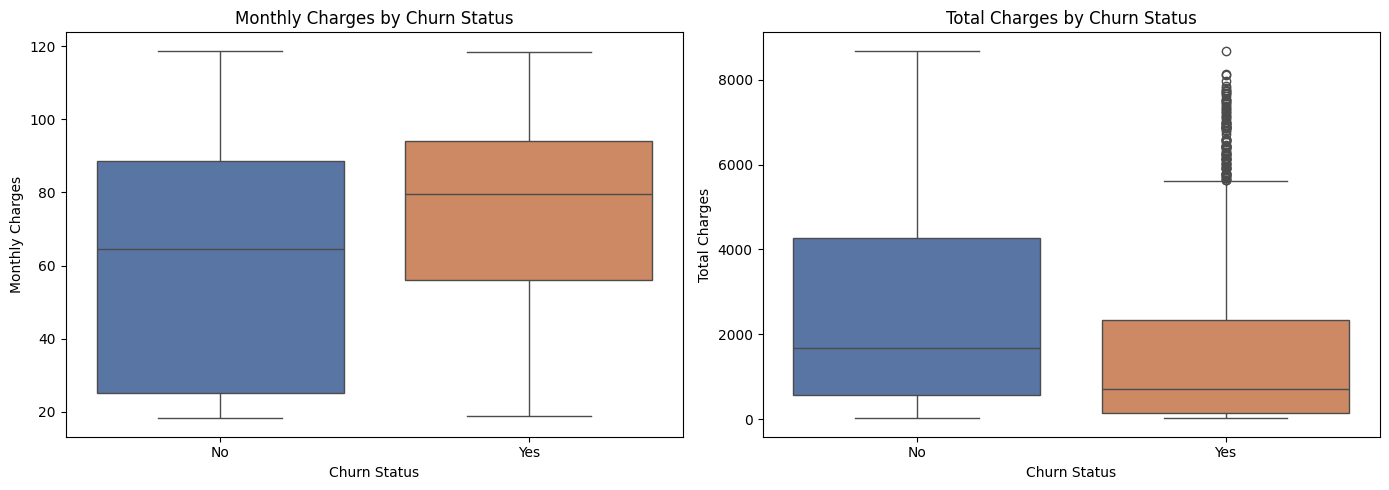

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=eda_df,
    x="Churn",
    y="MonthlyCharges",
    order=["No", "Yes"],
    hue="Churn",
    palette=churn_colors,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Monthly Charges by Churn Status")
axes[0].set_xlabel("Churn Status")
axes[0].set_ylabel("Monthly Charges")

sns.boxplot(
    data=eda_df,
    x="Churn",
    y="TotalCharges",
    order=["No", "Yes"],
    hue="Churn",
    palette=churn_colors,
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Total Charges by Churn Status")
axes[1].set_xlabel("Churn Status")
axes[1].set_ylabel("Total Charges")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / '04_charges_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Interpretation of Charges by Churn Status

Customers who churned had a higher median monthly charge than customers who
remained. The median monthly charge for churned customers is approximately 80,
compared with approximately 65 for customers who did not churn. This suggests
that higher monthly charges are associated with churn.

In contrast, customers who churned had lower median total charges. This does not
necessarily mean that lower total charges encourage churn. Total charges
accumulate over time, and the previous tenure analysis showed that churned
customers generally had shorter customer relationships. Their lower total
charges are therefore likely connected to their shorter tenure.

Several churned customers appear as high-value outliers in the total-charges
boxplot. These represent customers whose total charges are unusually high
relative to most other churned customers. They are plausible observations and
will not be removed solely because the boxplot identifies them as outliers.

Overall, monthly charges and total charges show different relationships with
churn and should be interpreted alongside customer tenure. These patterns
represent associations rather than evidence that charges directly cause churn.

### Contract Type and Churn

Churn rates are calculated within each contract type. Rates are used instead of
raw counts because the contract groups may contain different numbers of
customers.

In [111]:
# Calculate customer count and churn rate for each contract type
contract_summary = (
    eda_df.groupby("Contract")
    .agg(
        Customer_Count=("customerID", "count"),
        Churn_Rate=("ChurnFlag", "mean")
    )
    .reset_index()
)

contract_summary["Churn_Percentage"] = (
    contract_summary["Churn_Rate"] * 100
)

contract_summary = contract_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

display(
    contract_summary[
        ["Contract", "Customer_Count", "Churn_Percentage"]
    ].round(2)
)

,Contract,Customer_Count,Churn_Percentage
0,Month-to-month,3875,42.71
1,One year,1472,11.28
2,Two year,1685,2.85


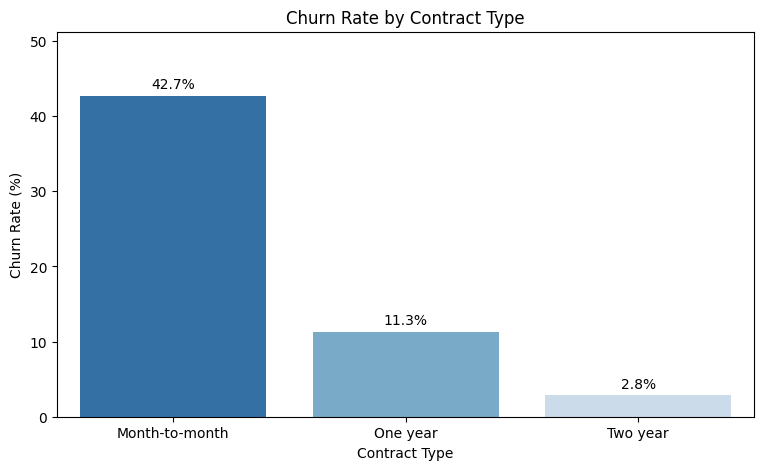

In [112]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=contract_summary,
    x="Contract",
    y="Churn_Percentage",
    hue="Contract",
    palette="Blues_r",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, contract_summary["Churn_Percentage"].max() * 1.2)

plt.savefig(
    OUTPUT_DIR / "05_churn_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Month-to-month customers had the highest churn rate, while customers with
longer contracts had considerably lower churn rates. Contract type appears to
be strongly associated with retention and may become an important predictive
feature.

### Internet Service and Churn

Churn rates are compared across internet-service categories to investigate
whether the type of service is associated with customer departure.

In [113]:
# Calculate churn rate by internet-service category
internet_summary = (
    eda_df.groupby("InternetService")
    .agg(
        Customer_Count=("customerID", "count"),
        Churn_Rate=("ChurnFlag", "mean")
    )
    .reset_index()
)

internet_summary["Churn_Percentage"] = (
    internet_summary["Churn_Rate"] * 100
)

internet_summary = internet_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

display(
    internet_summary[
        ["InternetService", "Customer_Count", "Churn_Percentage"]
    ].round(2)
)

,InternetService,Customer_Count,Churn_Percentage
1,Fiber optic,3096,41.89
0,DSL,2416,19.00
2,No,1520,7.43


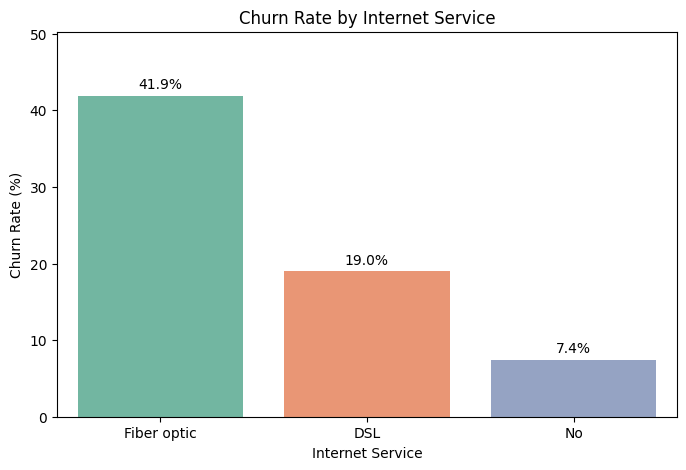

In [114]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=internet_summary,
    x="InternetService",
    y="Churn_Percentage",
    hue="InternetService",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, internet_summary["Churn_Percentage"].max() * 1.2)

plt.savefig(
    OUTPUT_DIR / "06_churn_by_internet_service.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Churn rates differ across internet-service categories. Fiber-optic customers
appear to have a higher churn rate than DSL customers and customers without
internet service.

### Payment Method and Churn

Payment methods are compared to determine whether particular billing behaviors
are associated with higher customer churn.

In [115]:
# Calculate churn rate by payment method
payment_summary = (
    eda_df.groupby("PaymentMethod")
    .agg(
        Customer_Count=("customerID", "count"),
        Churn_Rate=("ChurnFlag", "mean")
    )
    .reset_index()
)

payment_summary["Churn_Percentage"] = (
    payment_summary["Churn_Rate"] * 100
)

payment_summary = payment_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

display(
    payment_summary[
        ["PaymentMethod", "Customer_Count", "Churn_Percentage"]
    ].round(2)
)

,PaymentMethod,Customer_Count,Churn_Percentage
2,Electronic check,2365,45.29
3,Mailed check,1604,19.20
0,Bank transfer (automatic),1542,16.73
1,Credit card (automatic),1521,15.25


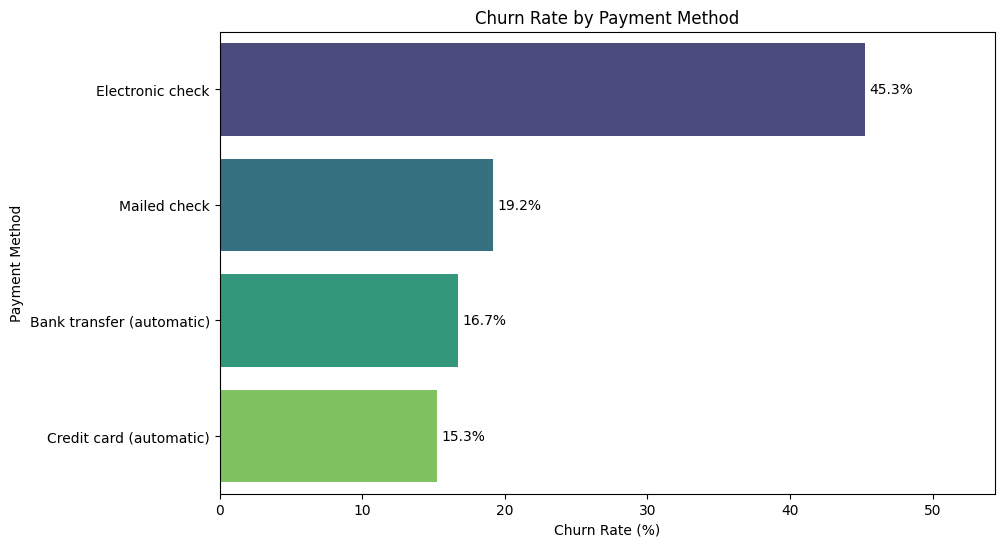

In [116]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=payment_summary,
    x="Churn_Percentage",
    y="PaymentMethod",
    hue="PaymentMethod",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.xlim(0, payment_summary["Churn_Percentage"].max() * 1.2)

plt.savefig(
    OUTPUT_DIR / "07_churn_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Customers using electronic checks had the highest observed churn rate. This
payment method may capture differences in customer preferences, contract types,
or billing experiences, so its relationship with other variables should be
considered during model interpretation.

### Support Services and Churn

Online security and technical-support subscriptions are examined because these
services may be associated with customer engagement and retention.

In [117]:
# Calculate churn rates for selected support-related services
support_features = ["OnlineSecurity", "TechSupport"]

support_results = []

for feature in support_features:
    feature_summary = (
        eda_df.groupby(feature)["ChurnFlag"]
        .mean()
        .mul(100)
        .reset_index(name="Churn_Percentage")
    )

    feature_summary["Feature"] = feature
    feature_summary = feature_summary.rename(
        columns={feature: "Category"}
    )

    support_results.append(feature_summary)

support_summary = pd.concat(
    support_results,
    ignore_index=True
)

display(
    support_summary[
        ["Feature", "Category", "Churn_Percentage"]
    ].round(2)
)

,Feature,Category,Churn_Percentage
0,OnlineSecurity,No,41.78
1,OnlineSecurity,No internet service,7.43
2,OnlineSecurity,Yes,14.64
3,TechSupport,No,41.65
4,TechSupport,No internet service,7.43
5,TechSupport,Yes,15.20


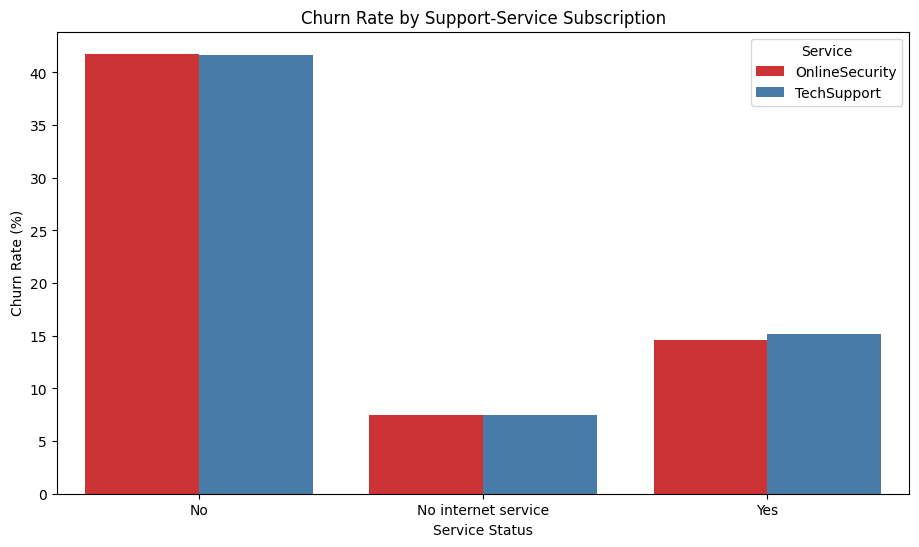

In [118]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=support_summary,
    x="Category",
    y="Churn_Percentage",
    hue="Feature",
    palette="Set1"
)

plt.title("Churn Rate by Support-Service Subscription")
plt.xlabel("Service Status")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Service")

plt.savefig(
    OUTPUT_DIR / "08_churn_by_support_services.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Customers without online security or technical support displayed higher churn
rates than customers subscribed to those services. These services may indicate
greater customer engagement, although the analysis does not demonstrate that
adding a support service would directly prevent churn.

### Demographic Characteristics and Churn

Churn rates are compared across selected demographic variables. These variables
may help identify patterns, but they should be interpreted carefully because
demographic differences can raise fairness considerations.

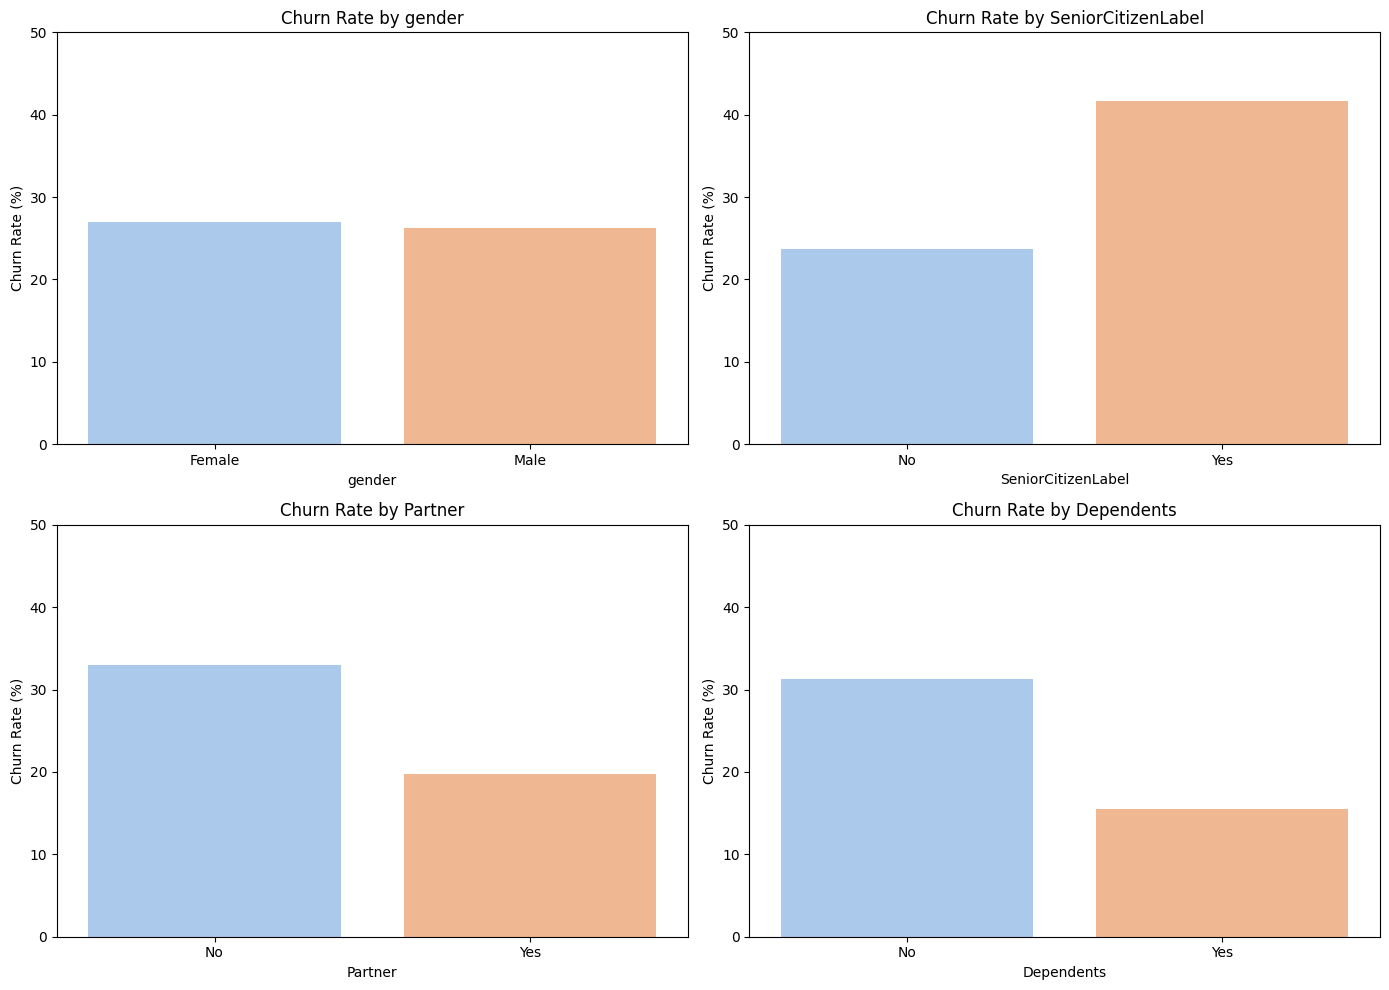

In [119]:
# Create readable labels for SeniorCitizen
eda_df["SeniorCitizenLabel"] = eda_df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

demographic_features = [
    "gender",
    "SeniorCitizenLabel",
    "Partner",
    "Dependents"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for axis, feature in zip(axes, demographic_features):
    demographic_rate = (
        eda_df.groupby(feature)["ChurnFlag"]
        .mean()
        .mul(100)
        .reset_index(name="Churn_Percentage")
    )

    sns.barplot(
        data=demographic_rate,
        x=feature,
        y="Churn_Percentage",
        hue=feature,
        palette="pastel",
        legend=False,
        ax=axis
    )

    axis.set_title(f"Churn Rate by {feature}")
    axis.set_xlabel(feature)
    axis.set_ylabel("Churn Rate (%)")
    axis.set_ylim(0, 50)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "09_churn_by_demographics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Gender shows relatively little difference in churn rate. Senior citizens
display a higher observed churn rate, while customers with partners or
dependents tend to show lower churn rates. These are group-level associations
and should not be interpreted as causal or used without considering potential
fairness implications.

### Numerical Correlations

A correlation heatmap is used to examine linear relationships among numerical
variables. Correlation values range from -1 to 1. Values near 1 indicate a
positive linear relationship, values near -1 indicate a negative relationship,
and values near zero indicate little linear relationship.

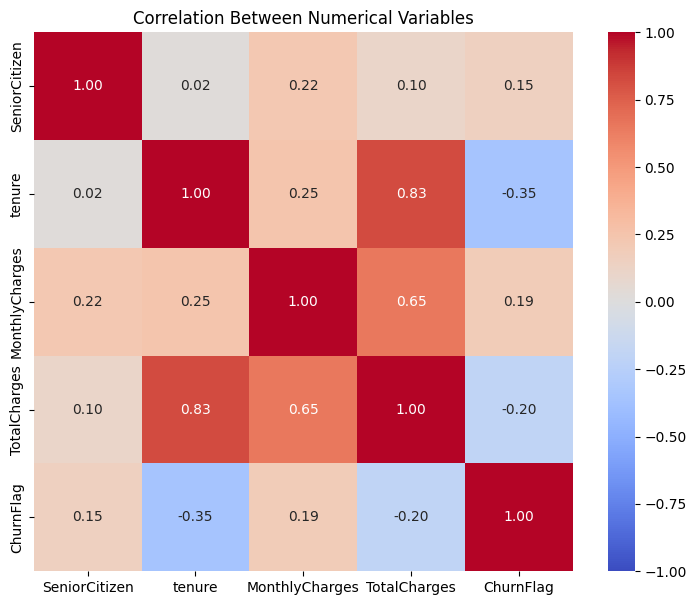

In [120]:
# Select numerical variables relevant to the analysis
correlation_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnFlag"
]

correlation_matrix = eda_df[correlation_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Between Numerical Variables")

plt.savefig(
    OUTPUT_DIR / "10_numerical_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Tenure has a negative correlation with churn, while monthly charges have a
positive correlation with churn. Total charges are strongly related to tenure,
which is expected because total charges accumulate over the duration of the
customer relationship. Correlation does not capture all relationships,
especially those involving categorical variables or nonlinear patterns.

In [121]:
# List the chart files saved during EDA
saved_charts = sorted(OUTPUT_DIR.glob("*.png"))

print(f"Number of saved charts: {len(saved_charts)}")

for chart in saved_charts:
    print(chart.name)

Number of saved charts: 16
01_churn_distribution.png
02_numerical_distributions.png
03_tenure_churn.png
04_charges_churn.png
05_churn_by_contract.png
06_churn_by_internet_service.png
07_churn_by_payment_method.png
08_churn_by_support_services.png
09_churn_by_demographics.png
10_numerical_correlation_heatmap.png
11_baseline_confusion_matrix.png
12_cross_validation_comparison.png
13_test_model_comparison.png
14_test_confusion_matrices.png
15_test_roc_curves.png
16_permutation_feature_importance.png


### Exploratory Data Analysis Summary

Approximately 26.6% of customers in the cleaned dataset churned, indicating a
moderate class imbalance. Therefore, accuracy alone will not be sufficient for
evaluating the machine learning models.

The exploratory analysis identified several important patterns:

- Customers who churned generally had shorter tenure.
- Month-to-month contracts had a substantially higher churn rate than one-year
  and two-year contracts.
- Churned customers typically had higher monthly charges but lower total
  charges. The lower total charges are likely connected to their shorter
  customer relationships.
- Churn rates differed across internet-service categories, with fiber-optic
  customers displaying the highest observed rate.
- Customers using electronic checks had a higher churn rate than customers
  using other payment methods.
- Customers without online security or technical support displayed higher
  observed churn rates.
- Senior citizens showed a higher churn rate, while customers with partners or
  dependents generally showed lower churn rates.
- Gender displayed relatively little difference in churn rate.

A numerical correlation heatmap was not included because most variables in the
dataset are categorical. The relevant numerical relationships were examined
directly using distributions, group statistics, and boxplots.

Overall, tenure, contract type, monthly charges, internet service, payment
method, and support-service subscriptions appear to be potentially useful
predictors of customer churn. Machine learning models will be used to evaluate
how effectively these variables predict churn when considered together.

These results show associations within a fictional sample dataset and do not
establish that any individual feature directly causes customer churn.

## 5. Data Preprocessing

Machine learning models require numerical input, but this dataset contains both
numerical and categorical variables. The preprocessing stage will:

- Remove the customer identifier from the predictor variables.
- Convert the target variable into numerical labels.
- Separate predictors from the target.
- Divide the data into training and test sets.
- Scale numerical features.
- Encode categorical features using one-hot encoding.
- Combine the transformations in a reusable preprocessing pipeline.

The training and test sets will be separated before the preprocessing
transformations are fitted. This prevents information from the test set from
leaking into model training.

### Predictors and Target Variable

The `Churn` column is the target variable. The remaining columns are potential
predictors, except for `customerID`, which is only a unique identifier and has
no meaningful predictive interpretation.

In [122]:
# Create the predictor matrix by removing the target and the customer identifier
X = df.drop(columns=["Churn", "customerID"])

# Convert the target labels into numerical values
# No = 0 means the customer stayed
# Yes = 1 means the customer churned
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print("Missing target values:", y.isna().sum())
print("Target values:", [int(val) for val in sorted(y.unique())])

Predictor shape: (7032, 19)
Target shape: (7032,)
Missing target values: 0
Target values: [0, 1]


After removing `customerID` and `Churn`, the predictor matrix contains 19
features. The target has been converted into binary numerical labels, where
`0` represents a customer who stayed and `1` represents a customer who churned.

### Training and Test Sets

The dataset is divided into training and test sets. The training set will be
used to develop the models, while the test set will be reserved for final
performance evaluation.

An 80/20 split is used. Stratification preserves approximately the same churn
proportion in both sets, and a fixed random state makes the split reproducible.

In [123]:
# Import function to divide the dataset
from sklearn.model_selection import train_test_split

# create 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42

)

print("Training predictors:", X_train.shape)
print("Test predictors:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training predictors: (5625, 19)
Test predictors: (1407, 19)
Training target: (5625,)
Test target: (1407,)


In [124]:
# Compare churn proportions in the full, training, and test datasets
class_proportions = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True),
    "Training Set": y_train.value_counts(normalize=True),
    "Test Set": y_test.value_counts(normalize=True)
}).sort_index()

# Convert proportions to percentages
class_proportions = class_proportions * 100

# Add class names
class_proportions.index = ["Stayed (0)", "Churned (1)"]

display(class_proportions.round(2))

,Full Dataset,Training Set,Test Set
Stayed (0),73.42,73.42,73.42
Churned (1),26.58,26.58,26.58


The churn proportions are nearly identical in the complete dataset, training
set, and test set. This confirms that stratification successfully preserved the
target distribution.

### Feature Types

Numerical and categorical features require different preprocessing steps.
Numerical columns will be scaled, while categorical columns will be converted
into numerical indicator columns.

In [125]:
# Identify numerical features using the training data only
numeric_features = (
    X_train.select_dtypes(include=np.number)
    .columns
    .tolist()
)

# Identify text and categorical features
categorical_features = (
    X_train.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


The dataset contains four numerical features and fifteen categorical features.
Although `SeniorCitizen` represents a yes/no characteristic, it is already
numerically encoded as 0 and 1 and can remain in the numerical group.

### Numerical Preprocessing

Numerical features will first be imputed using their median if missing values
are encountered. They will then be standardized so that features measured on
different scales can be compared more appropriately by scale-sensitive models
such as logistic regression.

Although the cleaned dataset currently contains no missing values, including an
imputer makes the pipeline more robust to future data.

In [126]:
# Import preprocessing and pipeline components
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Define the numerical preprocessing steps
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print(numeric_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


### Categorical Preprocessing

Categorical features will be imputed using their most frequent value if missing
data is encountered. One-hot encoding will then create numerical indicator
columns for each category.

`handle_unknown="ignore"` allows the pipeline to process a category in future
data that was not present during training without producing an error.

In [127]:
from sklearn.preprocessing import OneHotEncoder

# Define the categorical preprocessing steps
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print(categorical_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


### Combined Preprocessor

A `ColumnTransformer` applies the numerical pipeline only to numerical features
and the categorical pipeline only to categorical features. This combined
preprocessor can later be attached directly to each machine learning model.

In [128]:
from sklearn.compose import ColumnTransformer

# Combine numerical and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'O

### Preprocessing Verification

The preprocessor is fitted temporarily using only the training data to confirm
that all features can be transformed successfully. It is not fitted using the
test set, which remains reserved for final model evaluation.

In [129]:
# Fit the transformations using only the training data
X_train_transformed = preprocessor.fit_transform(X_train)

print("Original training shape:", X_train.shape)
print("Transformed training shape:", X_train_transformed.shape)
print("Transformed data type:", type(X_train_transformed))

Original training shape: (5625, 19)
Transformed training shape: (5625, 45)
Transformed data type: <class 'numpy.ndarray'>


In [130]:
# Convert the transformed data to a dense array only for verification
# The dataset is small enough for this temporary check
if hasattr(X_train_transformed, "toarray"):
    transformed_check = X_train_transformed.toarray()
else:
    transformed_check = X_train_transformed

print(
    "Missing values after preprocessing:",
    np.isnan(transformed_check).sum()
)

print(
    "Infinite values after preprocessing:",
    np.isinf(transformed_check).sum()
)

Missing values after preprocessing: 0
Infinite values after preprocessing: 0


In [131]:
# Remove the temporary dense copy to free memory
del transformed_check

The transformed training data contains no missing or infinite values. One-hot
encoding increased the number of columns because categorical variables were
expanded into separate binary indicators.

During model development, preprocessing and model training will be combined
inside a single scikit-learn pipeline. This ensures that preprocessing is
learned only from the training data during every fit or cross-validation fold,
helping prevent data leakage.

### Data Preprocessing Summary

The customer identifier was removed from the predictor variables because it
does not describe customer behavior. The target variable was converted from
`Yes` and `No` into binary labels, where `1` represents churn.

The cleaned dataset was divided into an 80% training set and a 20% test set
using stratification to preserve the churn distribution. The test set will
remain reserved for final performance evaluation.

Four numerical features and fifteen categorical features were identified.
Numerical variables will be median-imputed and standardized. Categorical
variables will be mode-imputed and one-hot encoded. These transformations were
combined in a reusable preprocessing pipeline and verified using only the
training data.

The next stage will establish a simple baseline model so that the machine
learning models can be evaluated against a minimum benchmark.

## 6. Baseline Model

A baseline model is established to provide a minimum performance benchmark and help determine
whether more advanced models are learning useful patterns.

A `DummyClassifier` using the most-frequent strategy will always predict the
majority class. Because most customers did not churn, this baseline will predict
that every customer stays.

The baseline does not learn relationships between customer characteristics and
churn. A useful machine learning model should outperform it, particularly in
its ability to identify customers who actually churn.

### Baseline Pipeline

The same preprocessing pipeline created in the data preprocessing section is combined with the
baseline classifier. Although the dummy model ignores the predictor values,
using the same pipeline maintains a consistent workflow for comparison with the
machine learning models.

In [132]:
# Import the baseline classifier
from sklearn.dummy import DummyClassifier

# Combine preprocessing with the dummy baseline model
baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyClassifier(strategy="most_frequent")
        )
    ]
)

print(baseline_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
               

### Baseline Training

The baseline pipeline is fitted using the training data. The preprocessing
steps are learned from the training predictors, while the dummy classifier
identifies the most frequent training target.

In [133]:
# Fit the preprocessing steps and baseline using the training data
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


### Baseline Predictions

The fitted baseline is used to predict the target labels for the previously
unseen test customers. Predicted probabilities are also generated for
calculating ROC-AUC.

In [134]:
# Predict whether each test customer stayed or churned
baseline_predictions = baseline_model.predict(X_test)

# Obtain the predicted probability of the positive class: churn
baseline_probabilties = baseline_model.predict_proba(
    X_test
)[:, 1]

print("Number of test predictions:", len(baseline_predictions))

print(
    "Unique predicted classes:",
    np.unique(baseline_predictions)
)

print(
    "Customers predicted tp churn",
    baseline_predictions.sum()
)

Number of test predictions: 1407
Unique predicted classes: [0]
Customers predicted tp churn 0


### Baseline Performance Metrics

The baseline is evaluated using several classification metrics:

- **Accuracy:** Proportion of all predictions that were correct.
- **Precision:** Among customers predicted to churn, the proportion that
  actually churned.
- **Recall:** Among customers who actually churned, the proportion identified by
  the model.
- **F1 score:** A balance between precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish between customers who
  stayed and customers who churned across classification thresholds.

Because churn is the minority class, recall, precision, F1, and ROC-AUC provide
more useful information than accuracy alone.

In [135]:
# Import classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate baseline metrics
baseline_metrics = {
    "Model": "Dummy Baseline",
    "Accuracy": accuracy_score(
        y_test,
        baseline_predictions
    ),
    "Precision": precision_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        baseline_probabilties
    )
}

# Display the results as a table
baseline_results_df = pd.DataFrame(
    [baseline_metrics]
)

display(
    baseline_results_df.round(3)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy Baseline,0.734,0.0,0.0,0.0,0.5


In [136]:
# Import the detailed classification report
from sklearn.metrics import classification_report

# Display performance separately for stayed and churned customers
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=[
            "Stayed",
            "Churned"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Stayed       0.73      1.00      0.85      1033
     Churned       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



### Baseline Confusion Matrix

A confusion matrix shows how the predicted classes compare with the actual
classes. It separates correct predictions from the two types of classification
errors.

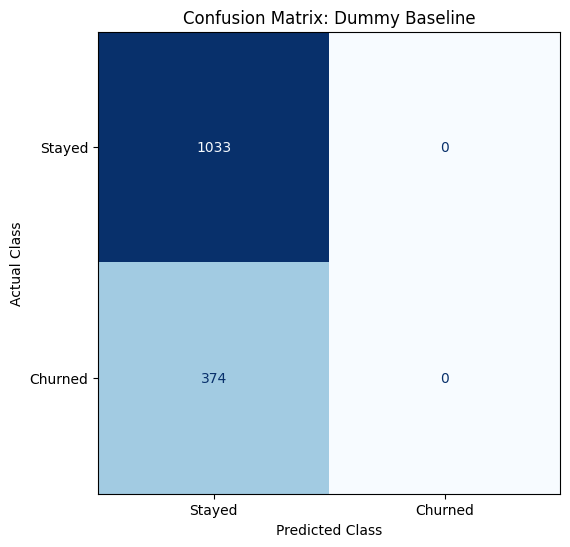

In [137]:
# Import the confusion-matrix display
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    display_labels=[
        "Stayed",
        "Churned"
    ],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

plt.title("Confusion Matrix: Dummy Baseline")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.savefig(
    OUTPUT_DIR / "11_baseline_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Confusion Matrix Interpretation

The baseline correctly classified all 1,033 customers who stayed. However, it
incorrectly classified all 374 customers who churned as customers who would
stay. It did not predict any customer as churned.

Although this produces an accuracy of approximately 73.4%, the model has zero
recall for churn because it failed to identify every churned customer. In a
customer-retention setting, these 374 false negatives are especially important
because the company would receive no warning about any of the customers who
actually left.

This confirms that the dummy baseline is not practically useful. Subsequent
models must identify churned customers rather than only predicting the majority
class.

The baseline model and its metrics are stored so they can later be compared
directly with the trained machine learning models.

In [138]:
# Begin a list that will store results for every model
model_results = [
    baseline_metrics
]

# Store trained pipelines for later evaluation and comparison
trained_models = {
    "Dummy Baseline": baseline_model
}

print("Baseline results stored successfully.")

Baseline results stored successfully.


### Baseline Model Summary

A most-frequent dummy classifier was established as the minimum performance
benchmark. The model predicted that every test customer would remain with the
company.

Although this strategy produced relatively high accuracy because of the class
imbalance, it had zero recall and zero F1 score for customer churn. It therefore
provides no practical value for identifying customers at risk of leaving.

Subsequent machine learning models should outperform the baseline by producing
an ROC-AUC above 0.50 and, most importantly, identifying a meaningful proportion
of the customers who actually churned.

## 7. Model Training

Two supervised machine learning models will be developed:

1. Logistic Regression
2. Decision Tree

These models were selected because they represent two different and relatively
interpretable classification approaches. Logistic Regression learns a weighted
relationship between the predictors and churn probability, while the Decision
Tree learns a sequence of feature-based decision rules.

Both models will use all 19 predictors prepared in Section 5. They will first be
evaluated using stratified five-fold cross-validation on the training set. The
separate test set will remain untouched until final evaluation in Section 8.

### Selected Models
#### Logistic Regression

Logistic Regression estimates the probability that a customer will churn. It
assigns a weight to each processed feature and combines the weighted values into
a probability between 0 and 1.

A positive feature weight indicates that the feature is associated with a
higher predicted probability of churn, while a negative weight indicates an
association with a lower predicted probability of churn.

Logistic Regression is useful because it is fast, produces probabilities, and
can be interpreted. Its main limitation is that it may not capture complicated
nonlinear relationships.

#### Decision Tree

A Decision Tree learns a sequence of questions about the predictors. For
example, it might first divide customers by contract type and then divide the
resulting groups by tenure or monthly charges.

Decision Trees can capture nonlinear relationships and interactions between
features. They are also relatively easy to explain. However, an unrestricted
tree can become overly complex and memorize the training data, a problem known
as overfitting.

### Model Variables

Both models will use the same 19 predictors.

The numerical predictors are:

- `SeniorCitizen`
- `tenure`
- `MonthlyCharges`
- `TotalCharges`

The categorical predictors are:

- `gender`
- `Partner`
- `Dependents`
- `PhoneService`
- `MultipleLines`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`
- `Contract`
- `PaperlessBilling`
- `PaymentMethod`

The target variable is `Churn`, encoded as:

- `0`: The customer stayed.
- `1`: The customer churned.

The `customerID` column is excluded because it is only an identifier and does
not describe customer behavior.

### Model Configuration

Balanced class weights are used because churned customers form the minority
class. This gives greater importance to mistakes involving churned customers
without generating artificial records.

The Decision Tree is limited to a depth of five and requires at least ten
training customers in each final leaf. These restrictions reduce the risk of
the tree memorizing individual training records.

In [139]:
# Import the two classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Define the models and their starting settings
model_definitions = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )
}

print("Models selected for training:")

for model_name in model_definitions:
    print("-", model_name)

Models selected for training:
- Logistic Regression
- Decision Tree


### Stratified Five-Fold Cross-Validation

Five-fold cross-validation divides the training data into five sections. The
model trains on four sections and validates on the remaining section. This is
repeated five times so that every section is used for validation once.

Stratification preserves approximately the same churn proportion in every fold.
This produces a more reliable performance estimate than relying on one
training-validation split.

Because preprocessing is included inside each model pipeline, the preprocessing
rules are learned separately within each training fold. This prevents
validation-data leakage.

In [140]:
# Import cross-validation tools
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

# Import a tool for creating customized metric scorers
from sklearn.metrics import make_scorer

# Create five reproducible stratified folds
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define the metrics calculated in each fold
scoring_metrics = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "roc_auc": "roc_auc"
}

print("Cross-validation configured successfully.")

Cross-validation configured successfully.


### Model Cross-Validation and Training

Each model is combined with an independent copy of the preprocessing pipeline.
Cross-validation is performed using only the training set.

After cross-validation, each pipeline is fitted using the entire training set
and stored for final evaluation on the untouched test set.

In [141]:
# Import clone so each model receives its own preprocessor
from sklearn.base import clone

# Create an empty list for cross-validation results
cross_validation_results = []

# Process each selected model
for model_name, estimator in model_definitions.items():

    print(f"Processing: {model_name}")

    # Combine preprocessing and the current model
    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                estimator
            )
        ]
    )

    # Evaluate the pipeline across five training folds
    fold_scores = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=-1,
        return_train_score=False
    )

    # Store average validation performance
    cross_validation_results.append({
        "Model": model_name,

        "CV Accuracy": fold_scores[
            "test_accuracy"
        ].mean(),

        "CV Precision": fold_scores[
            "test_precision"
        ].mean(),

        "CV Recall": fold_scores[
            "test_recall"
        ].mean(),

        "CV F1": fold_scores[
            "test_f1"
        ].mean(),

        "CV ROC-AUC": fold_scores[
            "test_roc_auc"
        ].mean(),

        "ROC-AUC Std": fold_scores[
            "test_roc_auc"
        ].std()
    })

    # Train the pipeline on the complete training set
    model_pipeline.fit(
        X_train,
        y_train
    )

    # Store the trained pipeline for Section 8
    trained_models[model_name] = model_pipeline

    print(f"Completed: {model_name}\n")

Processing: Logistic Regression
Completed: Logistic Regression

Processing: Decision Tree
Completed: Decision Tree



In [142]:
# Convert the collected results into a table
cv_results_df = pd.DataFrame(
    cross_validation_results
)

# Sort from highest to lowest average ROC-AUC
cv_results_df = cv_results_df.sort_values(
    by="CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    cv_results_df.round(3)
)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,ROC-AUC Std
0,Logistic Regression,0.752,0.522,0.802,0.632,0.846,0.005
1,Decision Tree,0.733,0.501,0.794,0.613,0.829,0.007


In [143]:
# Identify the model with the highest average cross-validation ROC-AUC
leading_cv_model = cv_results_df.loc[
    0,
    "Model"
]

leading_cv_roc_auc = cv_results_df.loc[
    0,
    "CV ROC-AUC"
]

print("Leading cross-validation model:", leading_cv_model)

print(
    f"Average cross-validation ROC-AUC: "
    f"{leading_cv_roc_auc:.3f}"
)

Leading cross-validation model: Logistic Regression
Average cross-validation ROC-AUC: 0.846


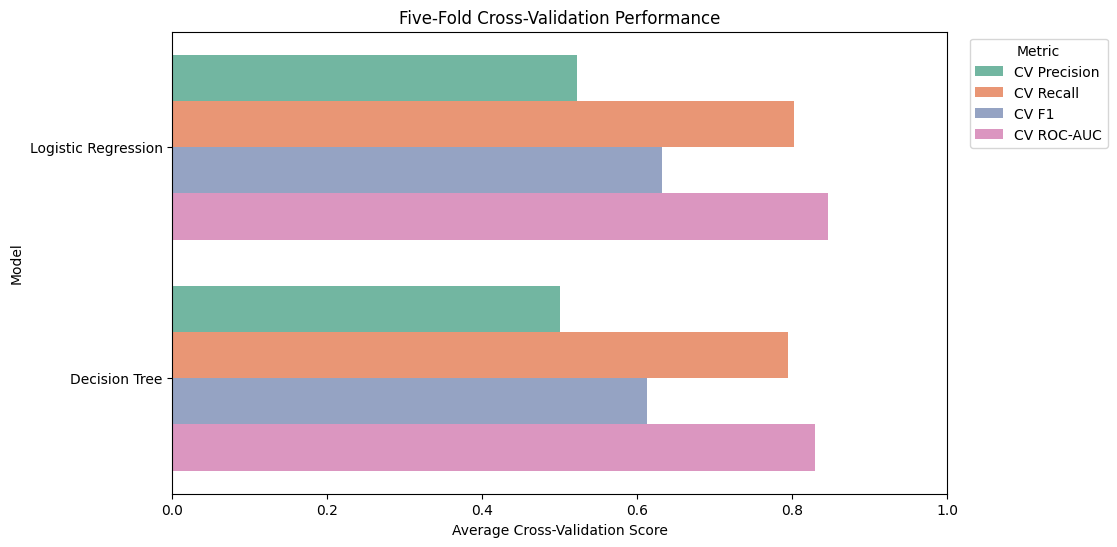

In [144]:
# Reshape the main metrics into a format suitable for plotting
cv_plot_data = cv_results_df[
    [
        "Model",
        "CV Precision",
        "CV Recall",
        "CV F1",
        "CV ROC-AUC"
    ]
].melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_plot_data,
    x="Score",
    y="Model",
    hue="Metric",
    palette="Set2"
)

plt.title("Five-Fold Cross-Validation Performance")
plt.xlabel("Average Cross-Validation Score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig(
    OUTPUT_DIR / "12_cross_validation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [145]:
# Define a permanent location for the cross-validation results
CV_RESULTS_PATH = (
    OUTPUT_DIR
    / "cross_validation_results.csv"
)

# Save the table without its pandas index
cv_results_df.to_csv(
    CV_RESULTS_PATH,
    index=False
)

print("Results saved to:")
print(CV_RESULTS_PATH)
print("File exists:", CV_RESULTS_PATH.exists())

Results saved to:
/content/drive/MyDrive/ML Projects/Telco Churn/outputs/cross_validation_results.csv
File exists: True


In [146]:
# Confirm that the baseline and trained models are available
print("Stored models:")

for model_name in trained_models:
    print("-", model_name)

Stored models:
- Dummy Baseline
- Logistic Regression
- Decision Tree


### Cross-Validation Interpretation

Both machine learning models achieved an average cross-validation ROC-AUC above
the dummy baseline benchmark of 0.50. This indicates that both models learned
meaningful patterns related to customer churn.

Logistic Regression achieved the highest average cross-validation ROC-AUC of
0.846 and the highest recall of 0.802. Decision Tree achieved an ROC-AUC of
0.829 and recall of 0.794. Logistic Regression was therefore selected.

The precision and recall scores demonstrate a tradeoff. Higher recall means
fewer churned customers are missed, while higher precision means a greater
proportion of churn warnings are correct. Recall is particularly important for
customer retention because a false negative represents a churned customer who
was not identified.

The test set was not used during this comparison and remains available for final
evaluation.

### Model Development and Training Summary

Logistic Regression and Decision Tree classifiers were trained using complete
preprocessing-and-model pipelines. Balanced class weights were applied because
churned customers form the minority class.

Each pipeline was evaluated through stratified five-fold cross-validation using
only the training data. Keeping preprocessing inside each pipeline prevented
information from validation folds from leaking into their training folds.

After cross-validation, both pipelines were trained using the complete training
set and stored for final test evaluation. Random Forest was not included in the
initial project to keep the analysis focused and interpretable. It could be
investigated as a future extension.

## 8. Performance Evaluation
The Dummy Baseline, Logistic Regression, and Decision Tree models will now be
evaluated using the untouched test set.

The following metrics will be compared:

- **Accuracy:** The proportion of all predictions that were correct.
- **Precision:** The proportion of churn predictions that were correct.
- **Recall:** The proportion of actual churned customers identified.
- **F1 score:** A balance between precision and recall.
- **ROC-AUC:** The model's ability to distinguish churned customers from
  customers who stayed across different classification thresholds.

Because the dataset is moderately imbalanced, recall, F1, and ROC-AUC are more
informative than accuracy alone. Recall is especially important because a false
negative represents a customer who churned without being identified.

### Test-Set Predictions

Each trained pipeline will generate class predictions and churn probabilities
for the test customers.

The class prediction is either `0` for stayed or `1` for churned. The predicted
probability indicates the model's estimated likelihood that a customer will
churn.

In [147]:
# Models included in the final evaluation
evaluation_model_names = [
    "Dummy Baseline",
    "Logistic Regression",
    "Decision Tree"
]

# Store predictions, probabilities, and metrics
test_predictions = {}
test_probabilities = {}
test_results = []

# Evaluate every selected model on the same test set
for model_name in evaluation_model_names:

    model = trained_models[model_name]

    # Generate predicted target classes
    predictions = model.predict(X_test)

    # Generate predicted probability of churn
    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    # Store outputs for later charts
    test_predictions[model_name] = predictions
    test_probabilities[model_name] = probabilities

    # Calculate performance metrics
    test_results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

    print(f"Evaluated: {model_name}")

Evaluated: Dummy Baseline
Evaluated: Logistic Regression
Evaluated: Decision Tree


In [148]:
# Convert the collected metrics into a table
test_results_df = pd.DataFrame(
    test_results
)

# Sort models by ROC-AUC
test_results_df = test_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    test_results_df.round(3)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.726,0.490,0.797,0.607,0.835
1,Decision Tree,0.733,0.499,0.794,0.613,0.828
2,Dummy Baseline,0.734,0.000,0.000,0.000,0.500


### Model Metric Comparison

The main classification metrics are visualized to make the differences among
the baseline and machine learning models easier to compare.

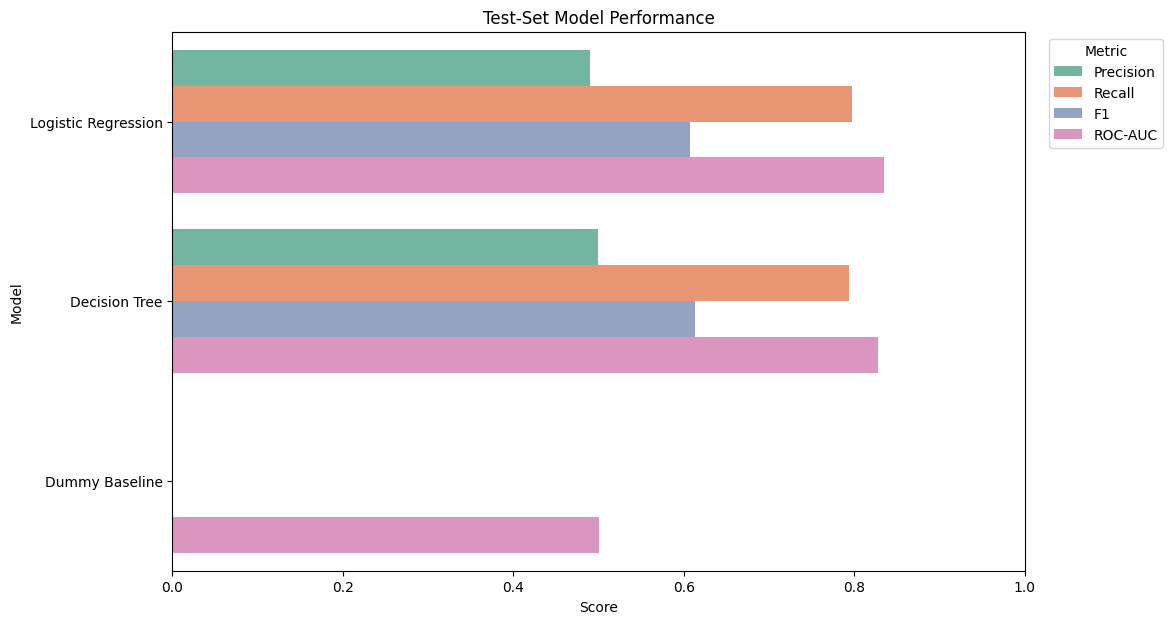

In [149]:
# Reshape the results table for visualization
test_plot_data = test_results_df[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
].melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=test_plot_data,
    x="Score",
    y="Model",
    hue="Metric",
    palette="Set2"
)

plt.title("Test-Set Model Performance")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig(
    OUTPUT_DIR / "13_test_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Cross-Validation and Test Comparison

Cross-validation estimates performance using different portions of the training
data. Test performance measures how well the fitted models generalize to the
untouched test customers.

Large differences between cross-validation and test performance could indicate
that a model is unstable or has overfit the training data.

In [150]:
# Compare validation and test scores for the two learning models
cv_test_comparison = cv_results_df[
    [
        "Model",
        "CV Recall",
        "CV F1",
        "CV ROC-AUC"
    ]
].merge(
    test_results_df[
        [
            "Model",
            "Recall",
            "F1",
            "ROC-AUC"
        ]
    ],
    on="Model",
    how="inner"
)

# Rename test columns for clarity
cv_test_comparison = cv_test_comparison.rename(
    columns={
        "Recall": "Test Recall",
        "F1": "Test F1",
        "ROC-AUC": "Test ROC-AUC"
    }
)

# Calculate the difference between validation and test ROC-AUC
cv_test_comparison["ROC-AUC Difference"] = (
    cv_test_comparison["CV ROC-AUC"]
    - cv_test_comparison["Test ROC-AUC"]
)

display(
    cv_test_comparison.round(3)
)

,Model,CV Recall,CV F1,CV ROC-AUC,Test Recall,Test F1,Test ROC-AUC,ROC-AUC Difference
0,Logistic Regression,0.802,0.632,0.846,0.797,0.607,0.835,0.011
1,Decision Tree,0.794,0.613,0.829,0.794,0.613,0.828,0.002


### Confusion Matrix Comparison

Confusion matrices show the specific correct predictions and errors produced by
each model.

For this project:

- A **true positive** is a churned customer correctly identified.
- A **true negative** is a staying customer correctly identified.
- A **false positive** is a staying customer incorrectly predicted to churn.
- A **false negative** is a churned customer incorrectly predicted to stay.

False negatives are especially important because they represent customers who
left without being identified as at risk.

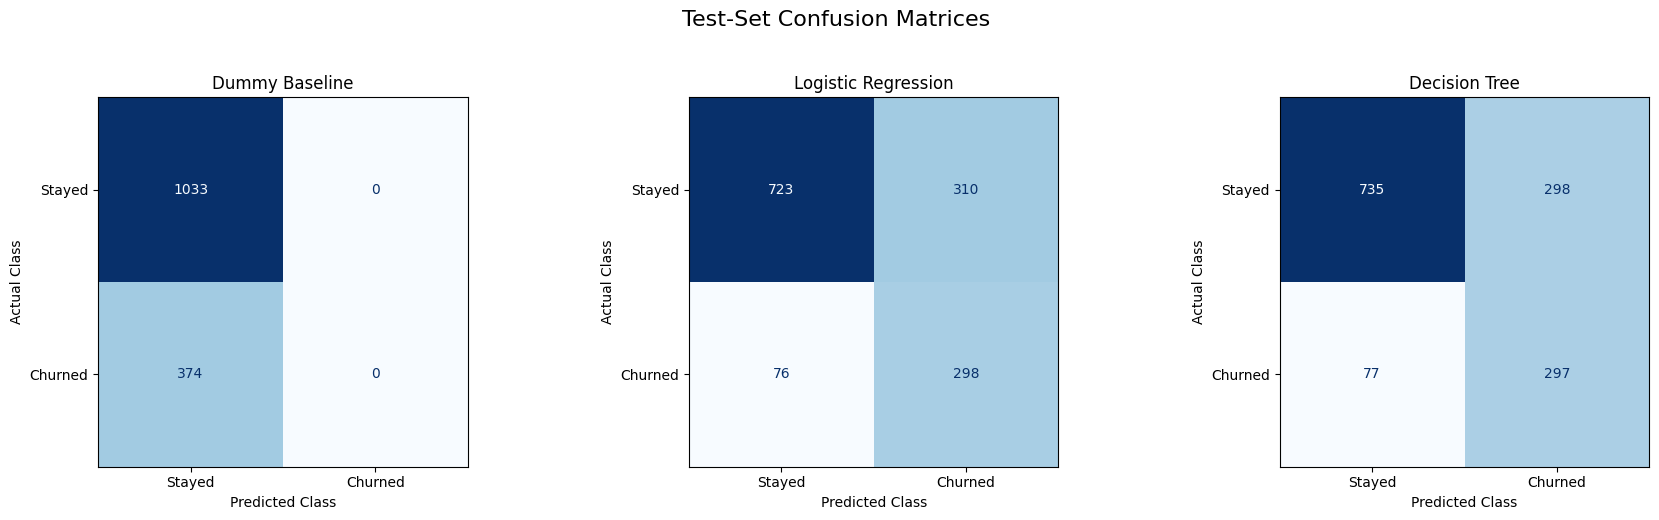

In [151]:
# Import confusion-matrix tools
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Create one confusion matrix for each model
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for axis, model_name in zip(
    axes,
    evaluation_model_names
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_predictions[model_name],
        display_labels=[
            "Stayed",
            "Churned"
        ],
        cmap="Blues",
        colorbar=False,
        ax=axis
    )

    axis.set_title(model_name)
    axis.set_xlabel("Predicted Class")
    axis.set_ylabel("Actual Class")

plt.suptitle(
    "Test-Set Confusion Matrices",
    fontsize=16,
    y=1.03
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "14_test_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ROC Curve Comparison

The Receiver Operating Characteristic curve displays the tradeoff between the
true-positive rate and false-positive rate across different classification
thresholds.

A curve closer to the upper-left corner indicates better discrimination. The
diagonal reference line represents performance similar to random guessing, with
an ROC-AUC of 0.50.

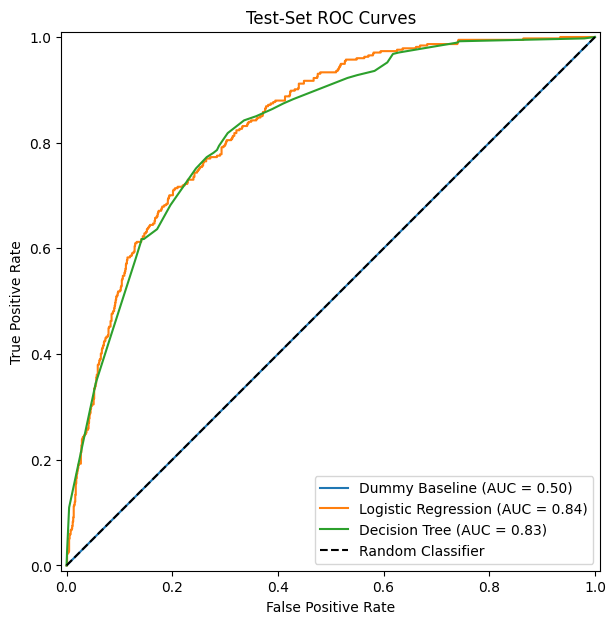

In [152]:
# Import the ROC curve display
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(
    figsize=(8, 7)
)

for model_name in evaluation_model_names:
    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities[model_name],
        name=model_name,
        ax=ax
    )

# Add the random-classification reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

plt.title("Test-Set ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.savefig(
    OUTPUT_DIR / "15_test_roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Final Model Selection

The final model is selected using average cross-validation ROC-AUC rather than
choosing whichever model happens to produce the highest test score. This avoids
changing the decision after observing the test results.

The selected model's test results provide the final estimate of its
generalization performance.

In [153]:
# Use the leading model identified through cross-validation
final_model_name = leading_cv_model

# Retrieve its trained pipeline
final_model = trained_models[
    final_model_name
]

# Retrieve its test metrics
final_model_results = test_results_df.loc[
    test_results_df["Model"] == final_model_name
].iloc[0]

print("Selected final model:", final_model_name)

print(
    f"Test accuracy: "
    f"{final_model_results['Accuracy']:.3f}"
)

print(
    f"Test precision: "
    f"{final_model_results['Precision']:.3f}"
)

print(
    f"Test recall: "
    f"{final_model_results['Recall']:.3f}"
)

print(
    f"Test F1 score: "
    f"{final_model_results['F1']:.3f}"
)

print(
    f"Test ROC-AUC: "
    f"{final_model_results['ROC-AUC']:.3f}"
)

Selected final model: Logistic Regression
Test accuracy: 0.726
Test precision: 0.490
Test recall: 0.797
Test F1 score: 0.607
Test ROC-AUC: 0.835


In [154]:
# Calculate the selected model's confusion-matrix values
final_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions[final_model_name]
)

true_negatives, false_positives, false_negatives, true_positives = (
    final_confusion_matrix.ravel()
)

print("True negatives:", true_negatives)
print("False positives:", false_positives)
print("False negatives:", false_negatives)
print("True positives:", true_positives)

True negatives: 723
False positives: 310
False negatives: 76
True positives: 298


In [155]:
# Display detailed performance for both target classes
print(
    classification_report(
        y_test,
        test_predictions[final_model_name],
        target_names=[
            "Stayed",
            "Churned"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Stayed       0.90      0.70      0.79      1033
     Churned       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [156]:
# Define the permanent results location
TEST_RESULTS_PATH = (
    OUTPUT_DIR
    / "test_model_results.csv"
)

# Save the test metrics
test_results_df.to_csv(
    TEST_RESULTS_PATH,
    index=False
)

print("Test results saved to:")
print(TEST_RESULTS_PATH)
print("File exists:", TEST_RESULTS_PATH.exists())

Test results saved to:
/content/drive/MyDrive/ML Projects/Telco Churn/outputs/test_model_results.csv
File exists: True


### Performance Evaluation Interpretation

The model correctly identified **298 of the 374 customers who actually
churned**, while missing **76 churned customers**. It also incorrectly classified
**310 customers who stayed** as likely to churn.
Although its accuracy of 72.6% was slightly lower than the Dummy Baseline's
73.4% accuracy, the Logistic Regression model was considerably more useful. The
baseline identified none of the churned customers, while Logistic Regression
identified approximately 79.7% of them.
The model's precision of 49.0% means that approximately half of its churn
warnings were correct. The remaining warnings were false positives, which could
result in retention offers being sent to customers who were not planning to
leave.
The 76 false negatives are potentially more costly because they represent
customers who churned without being identified for a possible retention
intervention.
The ROC-AUC of 0.835 indicates that the model demonstrated good ability to
distinguish customers who churned from customers who stayed across different
classification thresholds.


### Performance Evaluation Summary

The final model selected through cross-validation was **Logistic Regression**. On the untouched test set, it achieved:
- Accuracy: **0.726**
- Precision: **0.490**
- Recall: **0.797**
- F1 score: **0.607**
- ROC-AUC: **0.835**

The model correctly identified **298 of the 374 customers who actually
churned**, while missing **76 churned customers**. It also incorrectly classified**310 customers who stayed** as likely to churn.

Although its accuracy of 72.6% was slightly lower than the Dummy Baseline's
73.4% accuracy, the Logistic Regression model was considerably more useful. The
baseline identified none of the churned customers, while Logistic Regression
identified approximately 79.7% of them.

The model's precision of 49.0% means that approximately half of its churn
warnings were correct. The remaining warnings were false positives, which could
result in retention offers being sent to customers who were not planning to
leave.

The 76 false negatives are potentially more costly because they represent
customers who churned without being identified for a possible retention
intervention.

The ROC-AUC of 0.835 indicates that the model demonstrated good ability to
distinguish customers who churned from customers who stayed across different
classification thresholds.


## 9. Model Interpretation
Logistic Regression was selected as the final model based on its
cross-validation performance. The model achieved a test ROC-AUC of 0.835 and
identified 298 of the 374 customers who churned.

This section investigates which variables contributed most to its predictions.
Two interpretation methods will be used:

1. Permutation importance will measure the predictive usefulness of the
   original 19 variables.

These results represent predictive associations rather than causal effects.

In [157]:
# Confirm that the selected final model is Logistic Regression
print("Final model:", final_model_name)

print(
    "Estimator type:",
    type(
        final_model.named_steps["model"]
    ).__name__
)

print(
    "Test ROC-AUC:",
    round(
        final_model_results["ROC-AUC"],
        3
    )
)

Final model: Logistic Regression
Estimator type: LogisticRegression
Test ROC-AUC: 0.835


### Final Model Pipeline

The final model is a complete pipeline rather than only a Logistic Regression
estimator. It contains:

1. Median imputation and standardization for numerical variables.
2. Most-frequent imputation and one-hot encoding for categorical variables.
3. The fitted Logistic Regression classifier.

This allows the model to receive customer data in its original tabular form and
apply the required transformations automatically before producing a churn
prediction.

### Permutation Feature Importance

Permutation importance measures how much model performance decreases after the
values of one predictor are randomly shuffled.

Shuffling breaks the relationship between that predictor and churn while
leaving the other variables unchanged. If ROC-AUC decreases substantially, the
model relies heavily on that predictor. If ROC-AUC changes very little, the
predictor contributes less unique information to the model.

Each predictor will be shuffled 15 times to reduce the effect of random
variation.

In [158]:
# Import model-independent permutation importance
from sklearn.inspection import permutation_importance

# Measure feature importance using the fitted pipeline
permutation_result = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance calculated successfully.")

Permutation importance calculated successfully.


In [159]:
# Create a table using the original 19 predictor names
permutation_df = pd.DataFrame({
    "Feature": X_test.columns,

    "Importance": (
        permutation_result.importances_mean
    ),

    "Standard Deviation": (
        permutation_result.importances_std
    )
})

# Sort from most to least important
permutation_df = permutation_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(
    permutation_df.round(4)
)

,Feature,Importance,Standard Deviation
0,tenure,0.1751,0.0155
1,InternetService,0.0478,0.0064
2,Contract,0.0395,0.0075
3,MonthlyCharges,0.0308,0.0047
4,TotalCharges,0.0192,0.0043
5,StreamingMovies,0.0034,0.0023
6,PaperlessBilling,0.0034,0.0014
7,StreamingTV,0.0033,0.0018
8,TechSupport,0.0027,0.0024
9,PaymentMethod,0.0027,0.0020


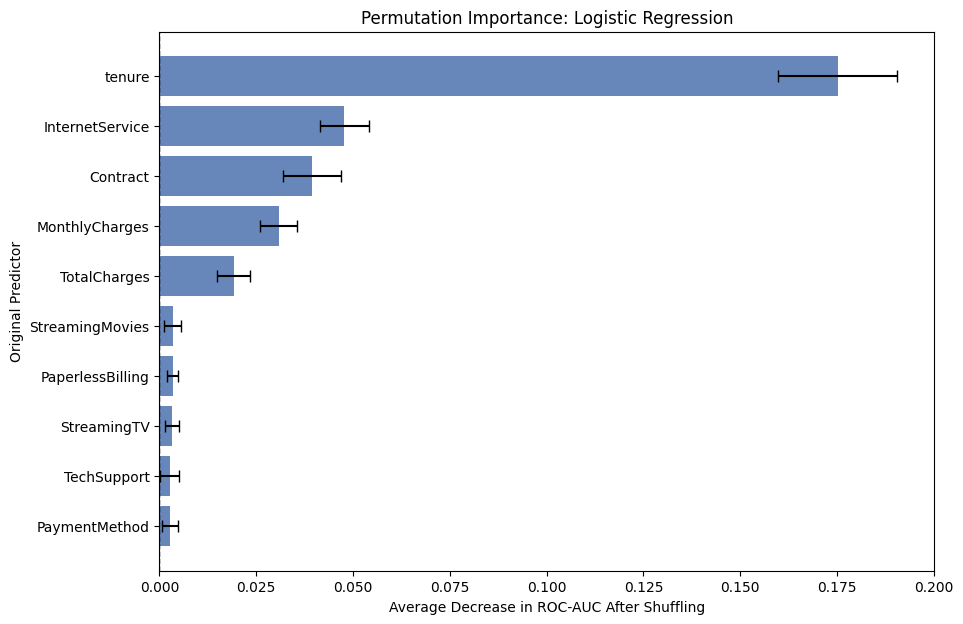

In [160]:
# Select the ten most important original predictors
top_permutation_features = (
    permutation_df
    .head(10)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation_features["Feature"],
    top_permutation_features["Importance"],
    xerr=top_permutation_features[
        "Standard Deviation"
    ],
    color="#4C72B0",
    alpha=0.85,
    capsize=4
)

# Mark zero importance
plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Permutation Importance: Logistic Regression"
)

plt.xlabel(
    "Average Decrease in ROC-AUC After Shuffling"
)

plt.ylabel("Original Predictor")

plt.savefig(
    OUTPUT_DIR
    / "16_permutation_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [161]:
# Save the permutation-importance table
PERMUTATION_PATH = (
    OUTPUT_DIR
    / "permutation_importance.csv"
)

permutation_df.to_csv(
    PERMUTATION_PATH,
    index=False
)

print("Permutation importance saved to:")
print(PERMUTATION_PATH)

Permutation importance saved to:
/content/drive/MyDrive/ML Projects/Telco Churn/outputs/permutation_importance.csv


### Permutation Importance Interpretation

The three predictors with the highest permutation importance were **tenure**,
**InternetService**, and **contract**. Shuffling these variables produced the largest
average reductions in ROC-AUC, indicating that Logistic Regression relied on
them most strongly when distinguishing churned customers from customers who
stayed.

Several predictors had importance values close to zero. This does not
necessarily mean that these variables have no relationship with churn. Some of
their information may overlap with more influential predictors.

Permutation importance measures predictive usefulness rather than direction.
It does not show whether a feature is associated with higher or lower predicted
churn. Logistic Regression coefficients will be examined next to determine
direction.

### Model Interpretation Summary

Logistic Regression was selected as the final model. It achieved a test ROC-AUC
of 0.835 and identified 298 of the 374 customers who churned.

Permutation importance identified **tenire**,
**Internet service**, and **contract**
as the most predictively useful original variables. Shuffling these features
caused the greatest reductions in ROC-AUC, indicating that the model relied on
them most strongly when distinguishing churned customers from customers who
stayed.

The permutation results were considered alongside the exploratory analysis,
which provided information about the direction of the observed relationships.
For example, Tenure was identified as an important predictor, and the exploratory analysis showed that customers with longer tenure generally had lower observed churn
rates than customers with shorter tenure.

Permutation importance measures predictive usefulness rather than causation.
The results do not prove that changing any individual customer characteristic
would directly prevent churn.

## 10. Conclusions and Limitations

### Conclusion

This project developed a Logistic Regression model to predict telecommunications
customer churn. After cleaning, the dataset contained 7,032 customers and 19
predictors.

Logistic Regression was selected through five-fold cross-validation, where it
achieved an average ROC-AUC of 0.846. On the untouched test set, it achieved an
ROC-AUC of 0.835, recall of 0.797, precision of 0.490, and F1 score of 0.607.
The similar cross-validation and test results suggest that the model generalized
reasonably well.

The model identified 298 of the 374 customers who churned and missed 76. It also
incorrectly predicted churn for 310 customers who stayed. Although its accuracy
was slightly lower than the Dummy Baseline, it was much more useful because the
baseline failed to identify any churned customers.

Permutation importance identified `tenure`, `InternetService`, and `Contract`
as the most predictively useful variables. The exploratory analysis also showed
that customers with longer tenure generally had lower observed churn, while
month-to-month customers had substantially higher churn rates.

### Limitations

The dataset represents a fictional company, so the results may not generalize
to real customers. The analysis identifies associations rather than causal
relationships.

The model also produced many false positives, and its default 0.50 threshold may
not provide the best balance between retention costs and missed churners.
Finally, this model was tested using only one dataset and has not been validated
using customers from another company or time period and might not be as accurate.